In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('/DENV/Database/SIVIGILA/210_denv.csv', encoding='latin1')
df['Departamento_ocurrencia'].unique()

array(['ATLANTICO', 'ANTIOQUIA', 'META', 'BOLIVAR',
       'PROCEDENCIA DESCONOCIDA', 'CUNDINAMARCA', 'SANTANDER', 'GUAJIRA',
       'CESAR', 'TOLIMA', 'HUILA', 'QUINDIO', 'CORDOBA', 'NARIÑO',
       'VALLE', 'CASANARE', 'VAUPES', 'MAGDALENA', 'CHOCO',
       'NORTE SANTANDER', 'EXTERIOR', 'BOYACA', 'CALDAS', 'ARAUCA',
       'CAUCA', 'CAQUETA', 'SAN ANDRES', 'AMAZONAS', 'GUAVIARE',
       'PUTUMAYO', 'VICHADA', 'GUAINIA', 'RISARALDA', 'SUCRE', 'BOGOTA'],
      dtype=object)

In [3]:
df = pd.read_csv('/DENV/2024/Metadata/210_denv.csv', encoding='latin1')

#Convert from departments to regions
# Define regions

region_dict = {'ATLANTICO':'Atlántico','ANTIOQUIA':'Antioquia','ARAUCA':'Arauca','BOLIVAR':'Bolívar','BOYACA':'Boyacá','CALDAS':'Caldas','CAQUETA':'Caquetá','CASANARE':'Casanare','CAUCA':'Cauca','CESAR':'Cesar','CHOCO':'Chocó','CORDOBA':'Córdoba','CUNDINAMARCA':'Cundinamarca','GUAINIA':'Guainía','GUAVIARE':'Guaviare','HUILA':'Huila','LA GUAJIRA':'La Guajira','MAGDALENA':'Magdalena','META':'Meta','NARIÑO':'Nariño','NORTE DE SANTANDER':'Norte de Santander','PUTUMAYO':'Putumayo','QUINDIO':'Quindío','RISARALDA':'Risaralda','SAN ANDRES Y PROVIDENCIA':'Archipiélago de San Andrés, Providencia y Santa Catalina','SANTANDER':'Santander','SUCRE':'Sucre','TOLIMA':'Tolima','VALLE DEL CAUCA':'Valle del Cauca','VALLE':'Valle del Cauca','VAUPES':'Vaupés','VICHADA':'Vichada','AMAZONAS':'Amazonas','GUAINIA':'Guainía','GUAVIARE':'Guaviare','VAUPES':'Vaupés','VICHADA':'Vichada','BOGOTA':'Bogotá D.C.'
}

df['Departamento'] = df['Departamento_ocurrencia'].map(region_dict)

caribbean = ['Archipiélago de San Andrés, Providencia y Santa Catalina','Atlántico', 'Bolívar', 'Magdalena', 'La Guajira', 'Cesar', 'Córdoba', 'Sucre']
andean = ['Cundinamarca', 'Caldas', 'Tolima','Antioquia', 'Boyacá', 'Huila', 'Santander', 'Norte de Santander', 'Quindío', 'Risaralda','Bogotá D.C.']
pacific = ['Valle del Cauca','Chocó','Cauca','Nariño']
amazonian = ['Amazonas', 'Caquetá', 'Guainía', 'Guaviare', 'Putumayo','Vaupés']
orinoquia = ['Arauca', 'Casanare', 'Meta', 'Vichada']

# Create a new column and use np.select to assign values to it using our lists as arguments
df['Region'] = np.select(
    [df['Departamento'].isin(caribbean), df['Departamento'].isin(andean), df['Departamento'].isin(pacific), df['Departamento'].isin(amazonian), df['Departamento'].isin(orinoquia)],
    ['Caribbean', 'Andean', 'Pacific', 'Amazonian', 'Orinoquia'],
    default='Other'
)

cutoff_date = pd.to_datetime('2023-12-31')
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])
df = df[df['FEC_NOT'] <= cutoff_date]

In [4]:
P_index = pd.read_csv('/DENV/2024/Climate_vars/P_index.csv')
P_index['State'] = P_index['State'].map(region_dict)
P_index['Region'] = np.select(
    [P_index['State'].isin(caribbean), P_index['State'].isin(andean), P_index['State'].isin(pacific), P_index['State'].isin(amazonian), P_index['State'].isin(orinoquia)],
    ['Caribbean', 'Andean', 'Pacific', 'Amazonian', 'Orinoquia'],
    default='Other'
)

In [5]:
#Rank the departments that have the most cases per region
P_index['Mean'].groupby(P_index['Region']).max()


Region
Amazonian     3.183071
Andean       14.289767
Caribbean    12.240496
Orinoquia     5.123762
Other        16.751767
Pacific       6.375716
Name: Mean, dtype: float64

In [9]:
#2024 data

data_2024 = pd.read_excel('/DENV/2024/Metadata/denv_cases_2024.xlsx')
data_2024['FEC_NOT'] = pd.to_datetime(data_2024['FEC_NOT'])
data_2024['Departamento'] = data_2024['Departamento_ocurrencia'].map(region_dict)
data_2024['Region'] = np.select(
    [data_2024['Departamento'].isin(caribbean), data_2024['Departamento'].isin(andean), data_2024['Departamento'].isin(pacific), data_2024['Departamento'].isin(amazonian), data_2024['Departamento'].isin(orinoquia)],
    ['Caribbean', 'Andean', 'Pacific', 'Amazonian', 'Orinoquia'],
    default='Other'
)

#Create a dictionary
city_to_dpt = {'BARRANQUILLA':'ATLANTICO','CARTAGENA':'BOLIVAR','SANTA MARTA D.E':'MAGDALENA','BUENAVENTURA':'Valle del Cauca'}
#Append to the other dictionary
city_to_dpt.update(region_dict)
data_2024['Departamento'] = data_2024['Departamento_ocurrencia'].map(city_to_dpt)

cutoff_date = pd.to_datetime('2024-01-01')

# Filter out rows where the date is beyond the cutoff date
data_2024 = data_2024[data_2024['FEC_NOT'] >= cutoff_date]
# Group by epidemiological week and region, then count observations
data_2024_grouped = data_2024.groupby([pd.Grouper(key='FEC_NOT'), 'Region'], as_index=False)['counts'].sum()

# Filter out the 'Other' regions
data_2024_grouped = data_2024_grouped[data_2024_grouped['Region'] != 'Other']
data_2024_grouped['counts'] = data_2024_grouped.groupby('Region')['counts'].diff().fillna(data_2024_grouped['counts'])
data_2024_grouped['counts'] = data_2024_grouped['counts'].clip(lower=0).astype(int)

#save data
data_2024_grouped.to_csv('/DENV/2024/Metadata/2024_grouped.csv')

In [10]:
#Function to darken the colors
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_37453/136225462.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  P_index['Mean_Smoothed'] = P_index.groupby(['Region', pd.Grouper(key='Date', freq='M')])['Mean'].transform('mean')


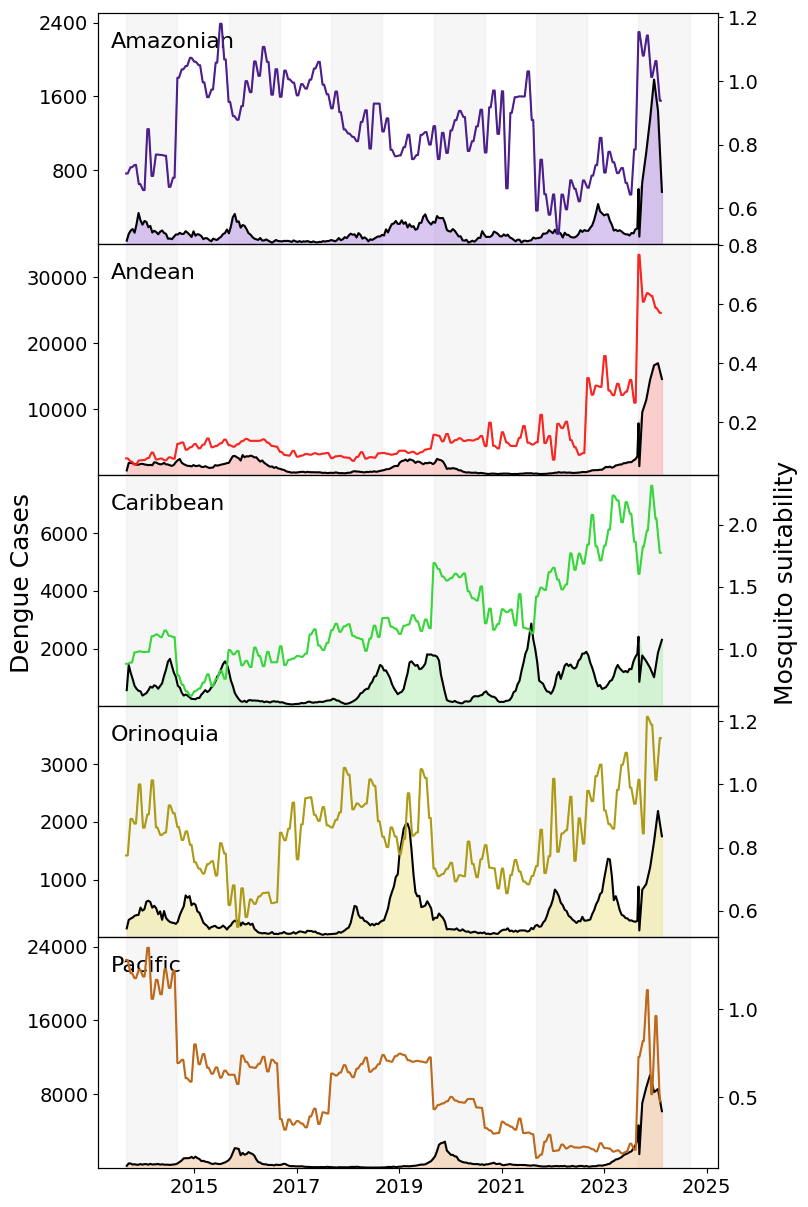

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from datetime import datetime

# Assuming your new DataFrame is named `P_index`
# Ensure the Date column is in datetime format
P_index['Date'] = pd.to_datetime(P_index['Date'])
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])

# Find the earliest date in P_index
earliest_date = P_index['Date'].min()

# Filter df_grouped to start from the earliest date in P_index
df_filtered = df[df['FEC_NOT'] >= earliest_date]

# Group by epidemiological week and region, then count observations
df_grouped = df_filtered.groupby([pd.Grouper(key='FEC_NOT', freq='2W-SUN'), 'Region']).size().reset_index(name='counts')
df_grouped = df_grouped[df_grouped['Region'] != 'Other']

# Smooth the Mean in P_index by month (30-day rolling mean) and calculate mean per region
P_index['Mean_Smoothed'] = P_index.groupby(['Region', pd.Grouper(key='Date', freq='M')])['Mean'].transform('mean')

df_grouped = pd.concat([df_grouped, data_2024_grouped], ignore_index=True)

#Filter the P index so it ends at the same time as the case data
P_index = P_index[P_index['Date'] <= df_grouped['FEC_NOT'].max()]

# Define Y-axis limits for each region
ylim_dict = {
    'Andean': (0, 35000),
    'Caribbean': (0, 8000),
    'Orinoquia': (0, 4000),
    'Amazonian': (0, 2500),
    'Pacific': (0, 25000)
}
# Define colors for each region
color_dict = {
    'Andean': '#FDA8A6',
    'Caribbean': '#AFEFB1',
    'Orinoquia': '#F1E58F',
    'Amazonian': '#B490E6',
    'Pacific': '#F1C297'
}

regions = df_grouped['Region'].unique()

fig, axes = plt.subplots(nrows=len(regions), ncols=1, figsize=(8, 3 * len(regions)))

if len(regions) == 1:
    axes = [axes]

from matplotlib.ticker import MaxNLocator

for ax, region in zip(axes, regions):
    region_data = df_grouped[df_grouped['Region'] == region]
    
    # Plot the line for counts (primary Y-axis)
    sns.lineplot(data=region_data, x='FEC_NOT', y='counts', ax=ax, color='k', zorder=101)

    ax.fill_between(region_data['FEC_NOT'], region_data['counts'], color=color_dict[region], alpha=0.5, zorder=100)
    
    # Add alternating gray blocks for every other year
    start_year = region_data['FEC_NOT'].dt.year.min()
    end_year = region_data['FEC_NOT'].dt.year.max()
    for year in range(start_year, end_year + 1, 2):
        ax.axvspan(datetime(year, 1, 1), datetime(year + 1, 1, 1), color='lightgrey', alpha=0.2, zorder=0)
    
    # Set the Y-axis limit
    ax.set_ylim(ylim_dict[region])

    # Set title inside the plot area
    ax.text(0.02, 0.85, region, transform=ax.transAxes, fontsize=16, ha='left')

    # Set the Y-axis ticks to show exactly 3 ticks, excluding zero
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.tick_params(axis='y', labelsize=14)

    # Secondary Y-axis for the mean per region
    ax2 = ax.twinx()
    region_mean_data = P_index[P_index['Region'] == region]
    sns.lineplot(data=region_mean_data, x='Date', y='Mean_Smoothed', ax=ax2, color=lighten_color(color_dict[region], 2.5), legend=False)
    ax2.set_ylabel('')
    ax2.tick_params(axis='y', labelsize=14)

    # Remove X and Y labels for individual plots
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Customize the spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
    
    if ax == axes[-1]:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', labelsize=14)
    else:
        ax.tick_params(axis='x', labelbottom=False)  # Hide X-axis labels for all but the bottom plot


# Set the common X-axis label
fig.text(0.015, 0.5, 'Dengue Cases', va='center', fontsize=18, rotation='vertical')
fig.text(0.97, 0.5, 'Mosquito suitability',rotation=90, va='center', fontsize=18)

# Adjust layout with no space between subplots
plt.subplots_adjust(hspace=0)

resolution = 1200
#plt.savefig('dengue_cases_by_region.jpeg', dpi=resolution, bbox_inches='tight', format='jpeg')
# Show the plot
plt.show()

In [35]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

# ---------------------------------------------
# Step 1: Bin and aggregate P_index using 2W-SUN anchor
# ---------------------------------------------
P_index['2W'] = pd.to_datetime(P_index['Date'])
P_index['2W'] = P_index['2W'].dt.to_period('2W-SUN').dt.start_time

P_index_agg = P_index.groupby(['2W', 'Region'])['Mean_Smoothed'].mean().reset_index()
P_index_agg.rename(columns={'2W': 'Date', 'Mean_Smoothed': 'P_index'}, inplace=True)

# ---------------------------------------------
# Step 2: Rename FEC_NOT in df_grouped to match P_index_agg
# ---------------------------------------------
df_grouped['Date'] = df_grouped['Date'].dt.to_period('2W-SUN').dt.start_time
merged = pd.merge(df_grouped, P_index_agg, on=['Date', 'Region'], how='inner')

# ---------------------------------------------
# Step 3: Merge on Region + Date (2-week bins)
# ---------------------------------------------
print(merged.head())
# ---------------------------------------------
# Step 4: Basic correlation analysis
# ---------------------------------------------
results = []

for region in merged['Region'].unique():
    region_df = merged[merged['Region'] == region]
    
    if len(region_df) < 3:
        continue
    
    # Spearman correlation
    rho, pval = spearmanr(region_df['counts'], region_df['P_index'])
    
    # Pearson correlation
    r, pval_pearson = pearsonr(region_df['counts'], region_df['P_index'])

    results.append({
        'Region': region,
        'Spearman_rho': round(rho, 3),
        'Spearman_pval': f'{pval:.2e}',
        'Pearson_r': round(r, 3),
        'Pearson_pval': f'{pval_pearson:.2e}'
    })

correlation_df = pd.DataFrame(results)

# ---------------------------------------------
# Step 5: Lead-lag correlation analysis (P_index leads by 2, 4, and 6 weeks)
# ---------------------------------------------
lead_results = []

for lag_weeks in [2, 4, 6]:
    shifted = merged.copy()
    shifted['Date_lagged'] = shifted['Date'] + pd.Timedelta(weeks=lag_weeks)

    # Prepare lagged version of P_index
    shifted = shifted[['Date_lagged', 'Region', 'P_index']].rename(columns={'Date_lagged': 'Date', 'P_index': 'P_index_lagged'})

    # Merge with original case data to align dates
    lagged_merged = pd.merge(df_grouped, shifted, on=['Date', 'Region'], how='inner')

    for region in lagged_merged['Region'].unique():
        region_df = lagged_merged[lagged_merged['Region'] == region]
        if len(region_df) < 3:
            continue

        # Compute correlation between case counts and lagged P_index
        rho, pval = spearmanr(region_df['counts'], region_df['P_index_lagged'])
        r, pval_pearson = pearsonr(region_df['counts'], region_df['P_index_lagged'])

        lead_results.append({
            'Region': region,
            'Lead (weeks)': lag_weeks,
            'Spearman_rho': round(rho, 3),
            'Spearman_pval': f'{pval:.2e}',
            'Pearson_r': round(r, 3),
            'Pearson_pval': f'{pval_pearson:.2e}'
        })

lead_lag_df = pd.DataFrame(lead_results)

# ---------------------------------------------
# Step 6: Debug information
# ---------------------------------------------
print(f"P_index_agg rows: {len(P_index_agg)}")
print(f"df_grouped rows: {len(df_grouped)}")
print(f"Merged rows: {len(merged)}")

print("P_index_agg dates:", P_index_agg['Date'].unique()[:5])
print("df_grouped dates:", df_grouped['Date'].unique()[:5])

# ---------------------------------------------
# Output correlation results
# ---------------------------------------------
print("\n--- Correlation without lag ---")
print(correlation_df)

print("\n--- Lead-lag correlation ---")
print(lead_lag_df.sort_values(by=['Region', 'Lead (weeks)']))

        Date     Region  counts   P_index
0 2013-12-30  Amazonian      39  0.709312
1 2013-12-30     Andean     729  0.078154
2 2013-12-30  Caribbean     559  0.884301
3 2013-12-30  Orinoquia     154  0.775014
4 2013-12-30    Pacific     268  1.279409
P_index_agg rows: 1896
df_grouped rows: 1345
Merged rows: 771
P_index_agg dates: <DatetimeArray>
['2013-12-30 00:00:00', '2014-01-06 00:00:00', '2014-01-27 00:00:00',
 '2014-02-03 00:00:00', '2014-02-10 00:00:00']
Length: 5, dtype: datetime64[ns]
df_grouped dates: <DatetimeArray>
['2013-12-30 00:00:00', '2014-01-13 00:00:00', '2014-01-27 00:00:00',
 '2014-02-10 00:00:00', '2014-02-24 00:00:00']
Length: 5, dtype: datetime64[ns]

--- Correlation without lag ---
      Region  Spearman_rho Spearman_pval  Pearson_r Pearson_pval
0  Amazonian        -0.454      3.25e-09     -0.274     5.92e-04
1     Andean         0.026      7.44e-01      0.343     1.26e-05
2  Caribbean         0.377      1.46e-06      0.375     1.60e-06
3  Orinoquia         0.3

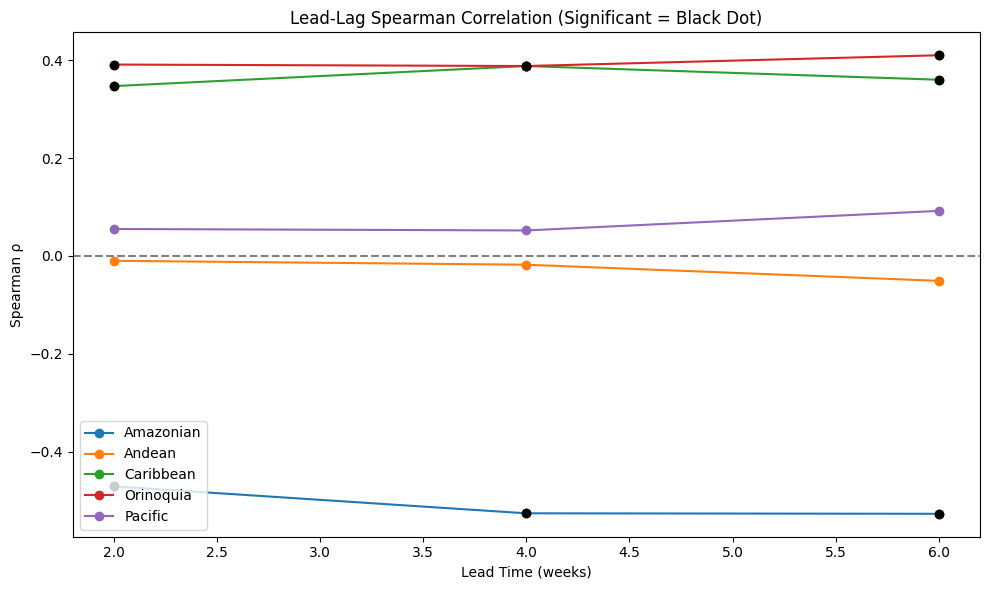

In [30]:
# Add significance marker to the lineplot
lead_lag_df['significant'] = lead_lag_df['Spearman_pval'].astype(float) < 0.05

plt.figure(figsize=(10, 6))
for region in lead_lag_df['Region'].unique():
    subset = lead_lag_df[lead_lag_df['Region'] == region]
    plt.plot(subset['Lead (weeks)'], subset['Spearman_rho'], label=region, marker='o')
    # Highlight significant points
    sig = subset[subset['significant']]
    plt.scatter(sig['Lead (weeks)'], sig['Spearman_rho'], color='black', zorder=5, label='_nolegend_')

plt.title('Lead-Lag Spearman Correlation (Significant = Black Dot)')
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel('Spearman ρ')
plt.xlabel('Lead Time (weeks)')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_37453/2509655145.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.47*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_matrix.loc[region, lead] = f"{val:.2f}{star}"
/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_37453/2509655145.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.53*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_matrix.loc[region, lead] = f"{val:.2f}{star}"
/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_37453/2509655145.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.53*' has dtype incompatible with float64, please explicitly

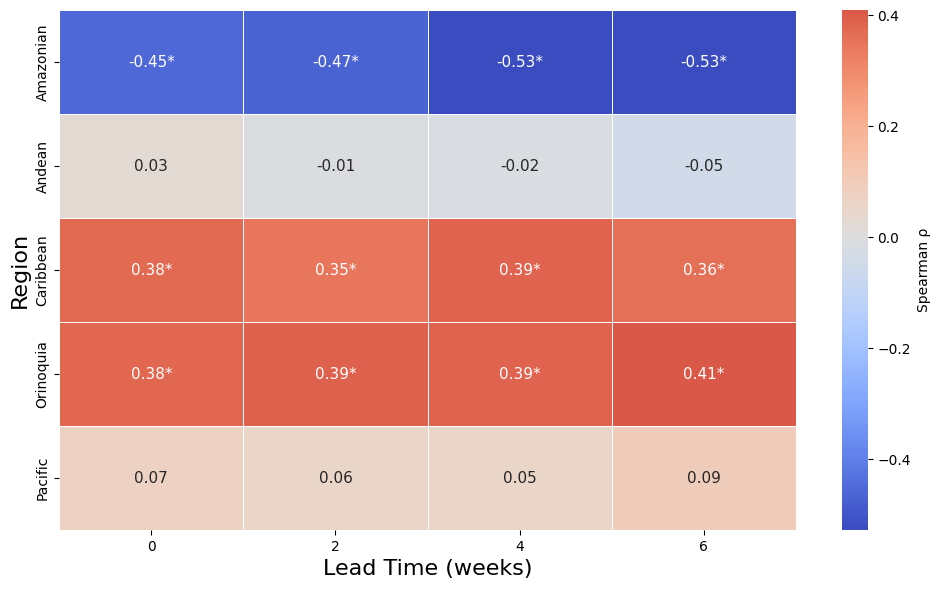

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare no-lag data with 'Lead (weeks)' = 0
correlation_df['Lead (weeks)'] = 0

correlation_df['Spearman_rho'] = pd.to_numeric(correlation_df['Spearman_rho'], errors='coerce')
correlation_df['Spearman_pval'] = pd.to_numeric(correlation_df['Spearman_pval'], errors='coerce')

lead_lag_combined = pd.concat([
    lead_lag_df[['Region', 'Lead (weeks)', 'Spearman_rho', 'Spearman_pval']],
    correlation_df[['Region', 'Lead (weeks)', 'Spearman_rho', 'Spearman_pval']]
], ignore_index=True)

# 3. Create an annotation matrix with asterisk for significance
annot_matrix = lead_lag_combined.pivot(index='Region', columns='Lead (weeks)', values='Spearman_rho').copy()

# Format annotations with asterisk if p < 0.05
for i, row in lead_lag_combined.iterrows():
    val = row['Spearman_rho']
    p = float(row['Spearman_pval'])
    star = '*' if p < 0.05 else ''
    region = row['Region']
    lead = row['Lead (weeks)']
    if pd.notnull(val):
        annot_matrix.loc[region, lead] = f"{val:.2f}{star}"
    else:
        annot_matrix.loc[region, lead] = ""

# 4. Plot heatmap using the actual rho values, annotate with significance
heatmap_data = lead_lag_combined.pivot(index='Region', columns='Lead (weeks)', values='Spearman_rho').astype(float)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)  # ensure lag is sorted
annot_matrix = annot_matrix.reindex(index=heatmap_data.index, columns=heatmap_data.columns)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=annot_matrix, fmt='', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Spearman ρ'}, linewidths=0.5, annot_kws={'size': 11})

plt.xlabel('Lead Time (weeks)', fontsize=16)
plt.ylabel('Region', fontsize=16)
plt.tight_layout()
plt.savefig('../Figures/lead_lag_correlation_heatmap.jpeg', dpi=300, bbox_inches='tight', format='jpeg')
plt.show()

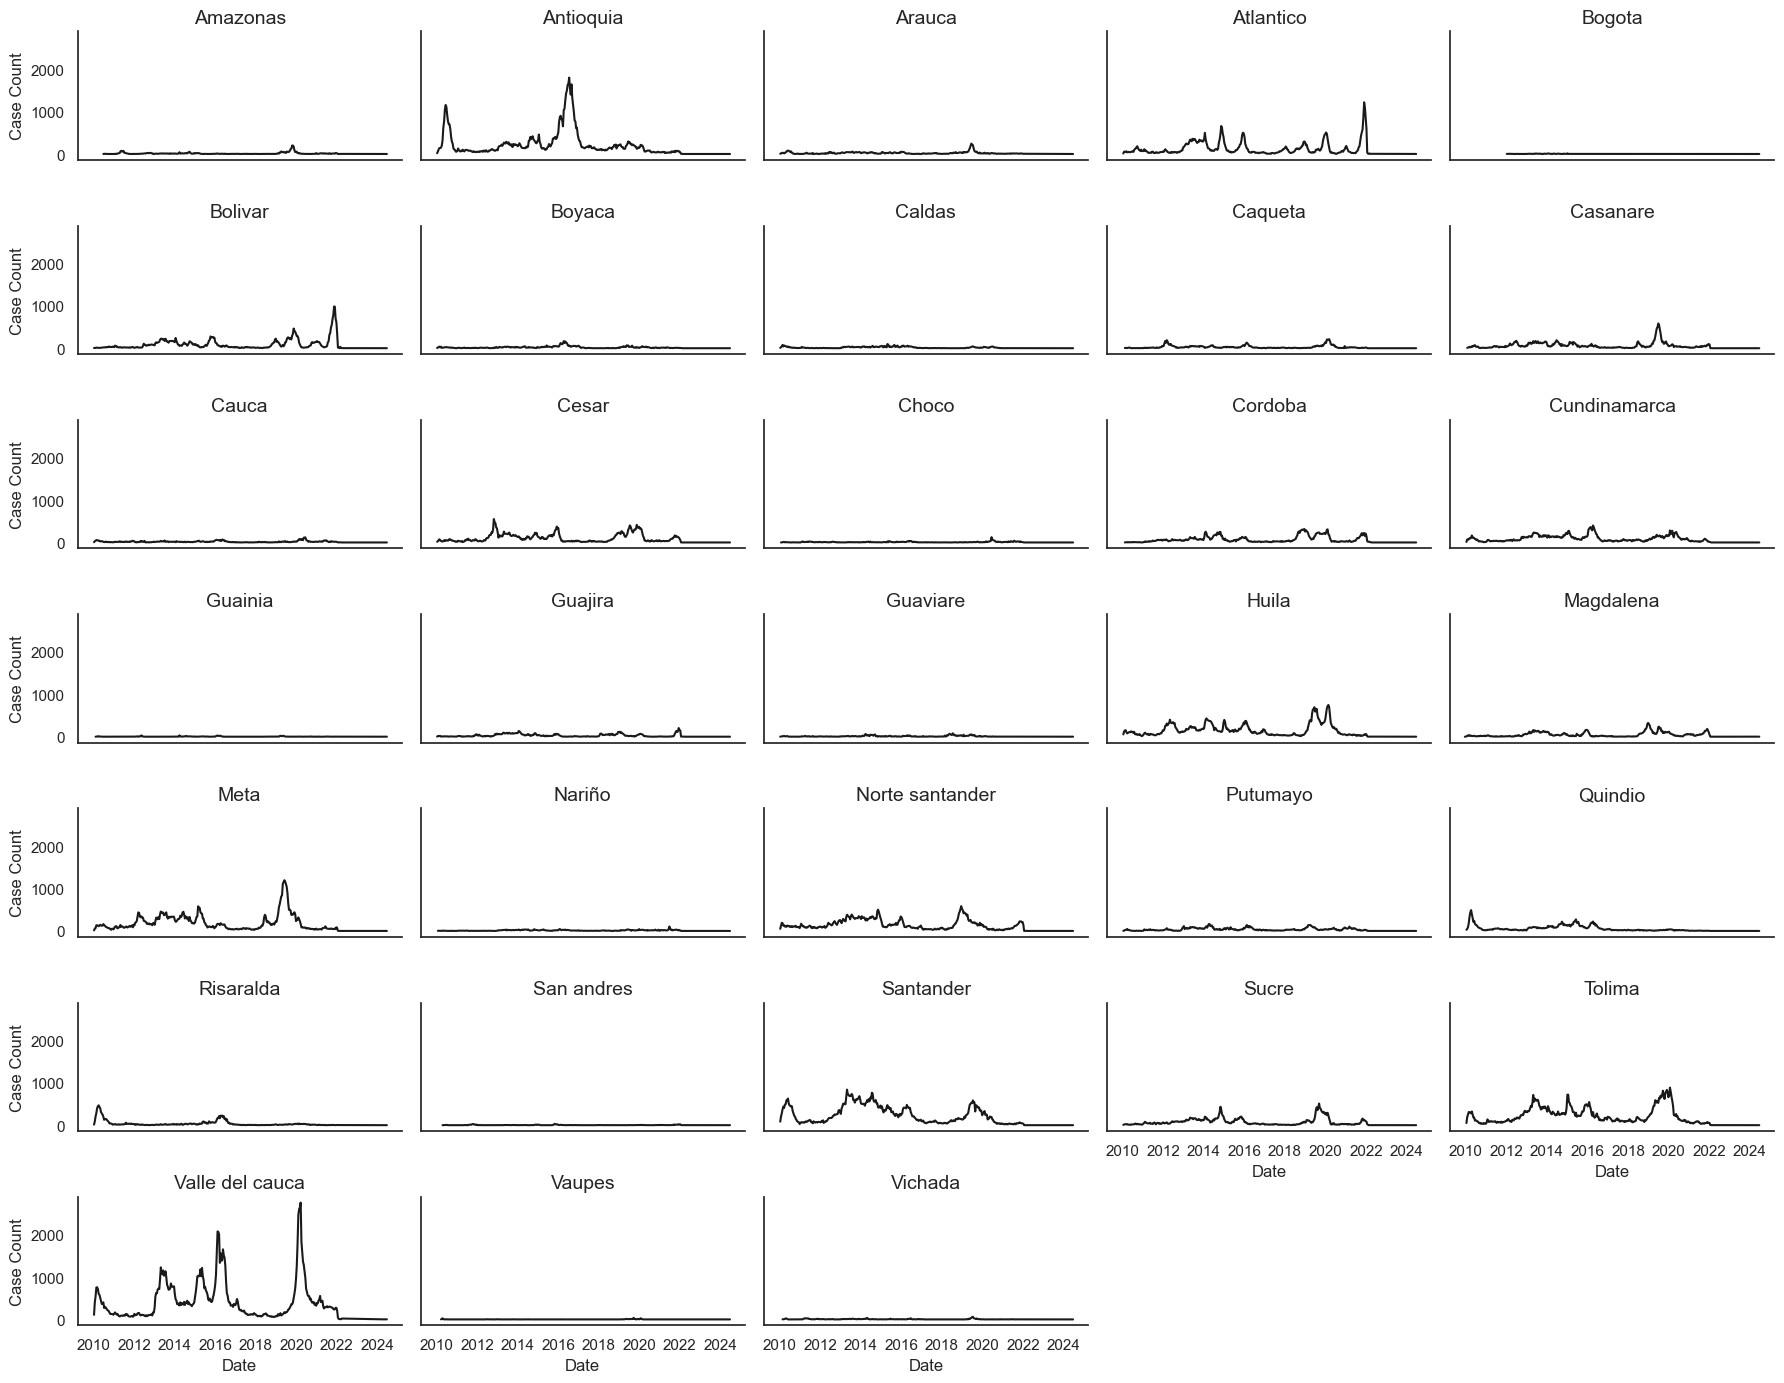

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_210 = pd.read_csv('/DENV/Database/SIVIGILA/210_denv.csv', encoding='latin1')
data_2024 = pd.read_excel('/DENV/2024/Metadata/denv_cases_2024.xlsx')

city_to_dpt = {
    "VALLE": "VALLE DEL CAUCA",
    "BARRANQUILLA": "ATLANTICO",
    "CARTAGENA": "BOLIVAR",
    "SANTA MARTA D.E": "MAGDALENA",
    "BUENAVENTURA": "VALLE DEL CAUCA",
    "CALI": "VALLE DEL CAUCA"
}

data_2024["Departamento_ocurrencia"] = data_2024["Departamento_ocurrencia"].map(city_to_dpt).fillna(data_2024["Departamento_ocurrencia"])
df_210["Departamento_ocurrencia"] = df_210["Departamento_ocurrencia"].map(city_to_dpt).fillna(df_210["Departamento_ocurrencia"])

combined_df = pd.concat([df_210, data_2024], ignore_index=True)
combined_df["FEC_NOT"] = pd.to_datetime(combined_df["FEC_NOT"], errors="coerce")
combined_df = combined_df.loc["2014-01-01":]
combined_df.set_index("FEC_NOT", inplace=True)

cases_2w = (
    combined_df
    .groupby(["Departamento_ocurrencia", pd.Grouper(freq="2W")])
    .size()
    .reset_index(name="cases")
)
cases_2w = cases_2w[~cases_2w["Departamento_ocurrencia"].isin(["PROCEDENCIA DESCONOCIDA", "EXTERIOR"])]
cases_2w.rename(columns={"FEC_NOT": "Date2W"}, inplace=True)

sns.set(style="white")
g = sns.relplot(
    data=cases_2w,
    x="Date2W", y="cases",
    col="Departamento_ocurrencia",
    kind="line",
    col_wrap=5,
    height=2, aspect=1.8,
    color="k"
)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_title(ax.get_title().capitalize(), fontsize=14)
g.set_axis_labels("Date", "Case Count")
plt.tight_layout()
#plt.savefig('../Figures/Supplementary/Supp4_dengue_cases_by_department.jpeg', dpi=300, bbox_inches='tight', format='jpeg')
plt.show()

In [ ]:
# import pandas as pd
# from great_tables import GT

# df_210 = pd.read_csv('/DENV/Database/SIVIGILA/210_denv.csv', encoding='latin1')
# data_2024 = pd.read_excel('/DENV/2024/Metadata/denv_cases_2024.xlsx')

# city_to_dpt = {
#     "VALLE": "VALLE DEL CAUCA",
#     "BARRANQUILLA": "ATLANTICO",
#     "CARTAGENA": "BOLIVAR",
#     "SANTA MARTA D.E": "MAGDALENA",
#     "BUENAVENTURA": "VALLE DEL CAUCA",
#     "CALI": "VALLE DEL CAUCA"
# }

# df_210["Departamento_ocurrencia"] = df_210["Departamento_ocurrencia"].map(city_to_dpt).fillna(df_210["Departamento_ocurrencia"])
# data_2024["Departamento_ocurrencia"] = data_2024["Departamento_ocurrencia"].map(city_to_dpt).fillna(data_2024["Departamento_ocurrencia"])

# combined_df = pd.concat([df_210, data_2024], ignore_index=True)
# combined_df["FEC_NOT"] = pd.to_datetime(combined_df["FEC_NOT"], errors="coerce")
# combined_df = combined_df.loc["2014-01-01":]
# combined_df["Year"] = combined_df["FEC_NOT"].dt.year
# filtered_df = combined_df[combined_df["Year"].isin([2021, 2022, 2023, 2024])]

# grouped = filtered_df.groupby(["Departamento_ocurrencia", "Year"]).size().reset_index(name="Cases")
# pivot_table = grouped.pivot(index="Departamento_ocurrencia", columns="Year", values="Cases").fillna(0).astype(int).reset_index()

# # Convert year columns to string for proper formatting
# pivot_table.columns = pivot_table.columns.map(lambda x: str(x) if x != "Departamento_ocurrencia" else x)

# # Sort the table by total cases (sum over 2021-2024)
# year_cols = ["2021", "2022", "2023", "2024"]

# pivot_table = pivot_table.sort_values("Total", ascending=False).drop(columns="Total").reset_index(drop=True)

# GT(pivot_table) \
#     .tab_header(title="DENV Cases by Department", subtitle="2021 to 2024") \
#     .fmt_number(columns=year_cols, compact=True)

# pivot_table

In [ ]:
total_cases = combined_df.groupby(pd.Grouper(key='FEC_NOT', freq='4W-SUN')).size().reset_index(name='counts')

total_cases = total_cases[total_cases['FEC_NOT'] >= '2020-01-01']

total_cases